In [1]:
# Data handling
import pandas as pd
import numpy as np

# For scaling and encoding
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# For splitting dataset
from sklearn.model_selection import train_test_split

# For machine learning models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# For evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
df=pd.read_csv("air_quality_data.csv")
df

,CO2,NO2,TEMPRATURE,HUMIDITY,AIR_QUALITY
0,0.44,16,22,40,Good
1,0.34,14,23,45,Good
2,0.56,18,25,50,Good
3,0.72,28,27,55,Moderate
4,1.25,45,31,62,Poor
...,...,...,...,...,...
494,1.48,52,33,64,Poor
495,0.32,12,22,44,Good
496,0.74,28,27,53,Moderate
497,1.61,58,35,69,Poor


In [2]:
df.describe()

,CO2,NO2,TEMPRATURE,HUMIDITY
count,499.000000,499.000000,499.000000,499.000000
mean,0.906513,33.549098,28.334669,55.699399
std,0.483695,17.268465,4.664467,9.169851
min,0.230000,10.000000,20.000000,40.000000
25%,0.460000,17.000000,24.000000,48.000000
50%,0.830000,32.000000,28.000000,54.000000
75%,1.395000,49.500000,32.000000,63.000000
max,1.920000,67.000000,38.000000,74.000000


In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:\n")
df.info()

Shape: (499, 5)

Columns:
 Index(['CO2', 'NO2 ', 'TEMPRATURE', 'HUMIDITY', 'AIR_QUALITY'], dtype='object')

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CO2          499 non-null    float64
 1   NO2          499 non-null    int64  
 2   TEMPRATURE   499 non-null    int64  
 3   HUMIDITY     499 non-null    int64  
 4   AIR_QUALITY  499 non-null    object 
dtypes: float64(1), int64(3), object(1)
memory usage: 19.6+ KB


In [4]:
df.head()

,CO2,NO2,TEMPRATURE,HUMIDITY,AIR_QUALITY
0,0.44,16,22,40,Good
1,0.34,14,23,45,Good
2,0.56,18,25,50,Good
3,0.72,28,27,55,Moderate
4,1.25,45,31,62,Poor


In [5]:
df.isnull().sum()

CO2            0
NO2            0
TEMPRATURE     0
HUMIDITY       0
AIR_QUALITY    0
dtype: int64

In [35]:
df

,CO2,NO2,TEMPRATURE,HUMIDITY,AIR_QUALITY
0,0.44,16,22,40,Good
1,0.34,14,23,45,Good
2,0.56,18,25,50,Good
3,0.72,28,27,55,Moderate
4,1.25,45,31,62,Poor
...,...,...,...,...,...
494,1.48,52,33,64,Poor
495,0.32,12,22,44,Good
496,0.74,28,27,53,Moderate
497,1.61,58,35,69,Poor


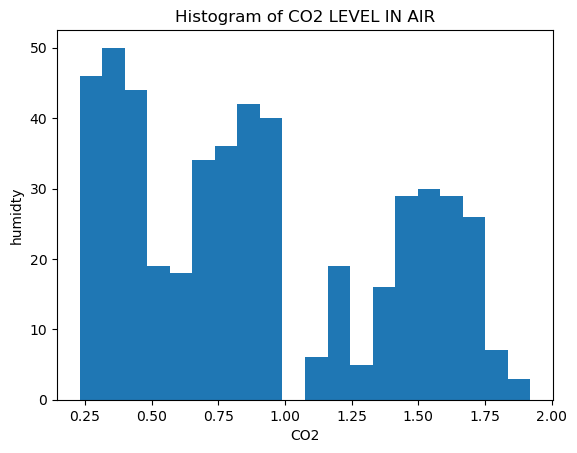

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
plt.hist(df["CO2"], bins=20,)
plt.title('Histogram of CO2 LEVEL IN AIR')
plt.xlabel("CO2")
plt.ylabel('humidty')
plt.show()

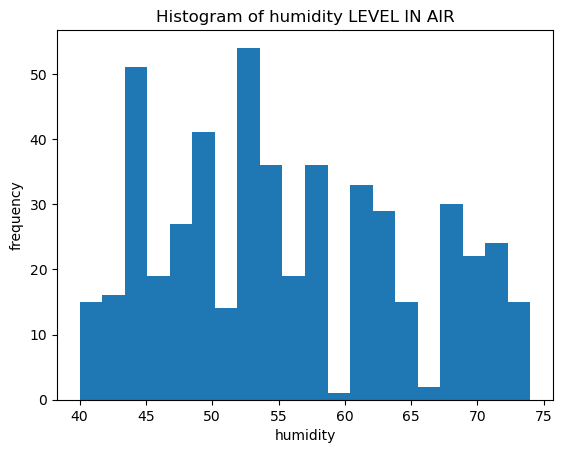

In [26]:
plt.figure()
plt.hist(df["HUMIDITY"], bins=20,)
plt.title('Histogram of humidity LEVEL IN AIR')
plt.xlabel("humidity")
plt.ylabel('frequency')
plt.show()

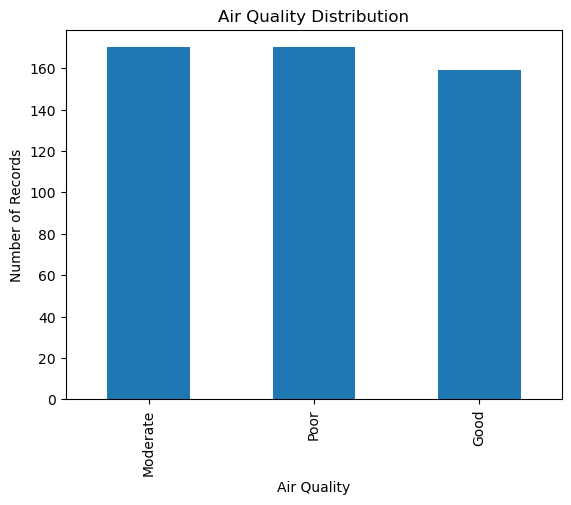

In [28]:
plt.figure()
df["AIR_QUALITY"].value_counts().plot(kind="bar")
plt.xlabel("Air Quality")
plt.ylabel("Number of Records")
plt.title("Air Quality Distribution")
plt.show()

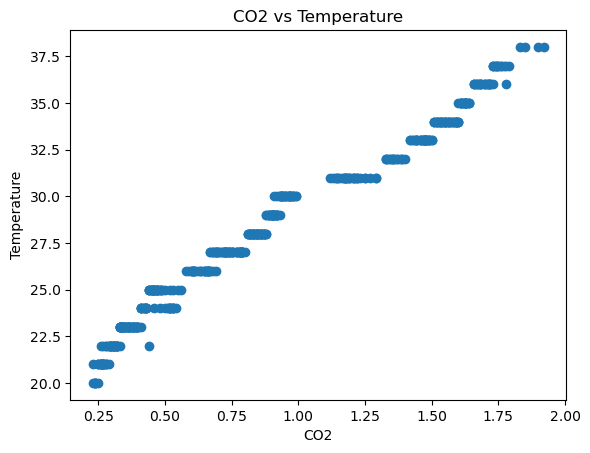

In [30]:
plt.figure()
plt.scatter(df["CO2"], df["TEMPRATURE"])
plt.xlabel("CO2")
plt.ylabel("Temperature")
plt.title("CO2 vs Temperature")
plt.show()

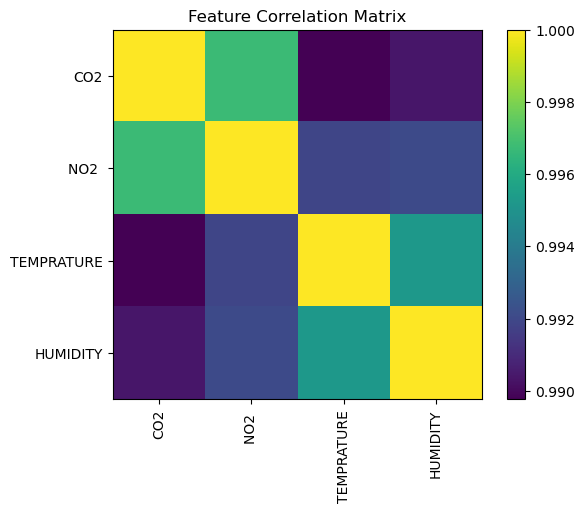

In [37]:
plt.figure()
corr = df[["CO2", "NO2 ", "TEMPRATURE", "HUMIDITY"]].corr()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Matrix")

plt.show()

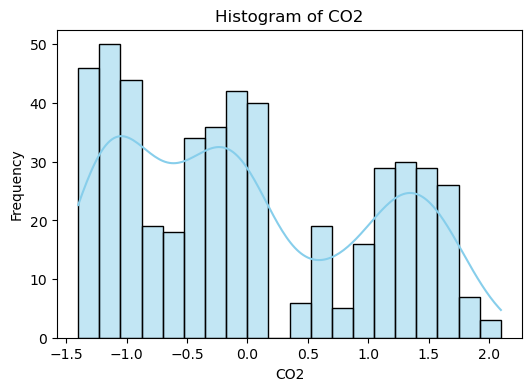

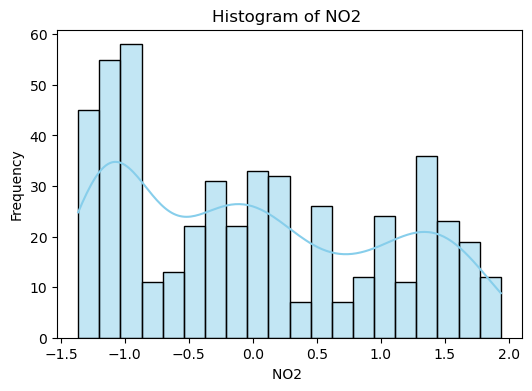

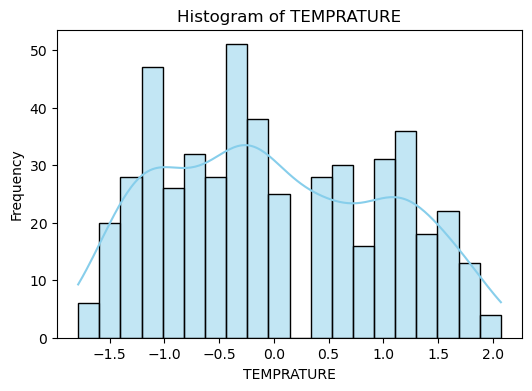

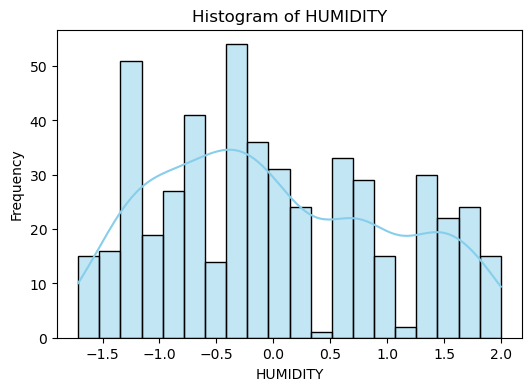

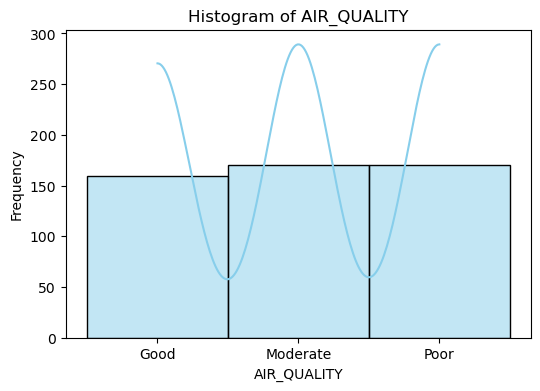

In [51]:
numeric_columns = ['CO2', 'NO2 ', 'TEMPRATURE', 'HUMIDITY', 'AIR_QUALITY']

for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [45]:
for col in ['CO2', 'NO2 ', 'TEMPRATURE', 'HUMIDITY']: 
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} -> Number of Outliers: {outliers.shape[0]}")

CO2 -> Number of Outliers: 0
NO2  -> Number of Outliers: 0
TEMPRATURE -> Number of Outliers: 0
HUMIDITY -> Number of Outliers: 0


In [50]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = ["CO2", "NO2 ", "TEMPRATURE", "HUMIDITY"]
scaler = StandardScaler()

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
df

,CO2,NO2,TEMPRATURE,HUMIDITY,AIR_QUALITY
0,-0.965445,-1.017271,-1.359432,-1.713785,Good
1,-1.172395,-1.133205,-1.144830,-1.167973,Good
2,-0.717106,-0.901337,-0.715626,-0.622160,Good
3,-0.385987,-0.321665,-0.286423,-0.076348,Moderate
4,0.710844,0.663776,0.571985,0.687789,Poor
...,...,...,...,...,...
494,1.186827,1.069546,1.001189,0.906114,Poor
495,-1.213785,-1.249140,-1.359432,-1.277135,Good
496,-0.344598,-0.321665,-0.286423,-0.294673,Moderate
497,1.455861,1.417349,1.430393,1.451926,Poor


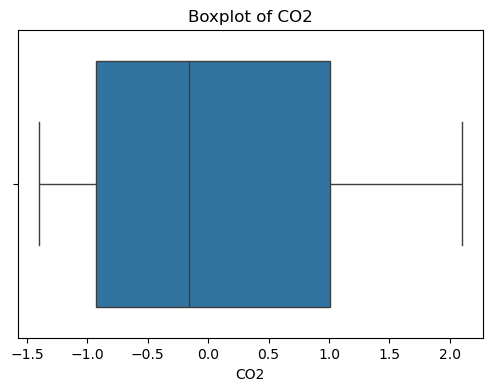

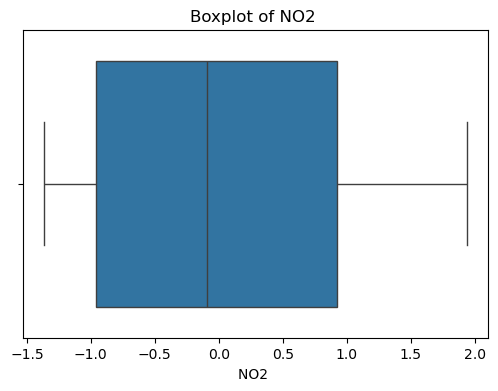

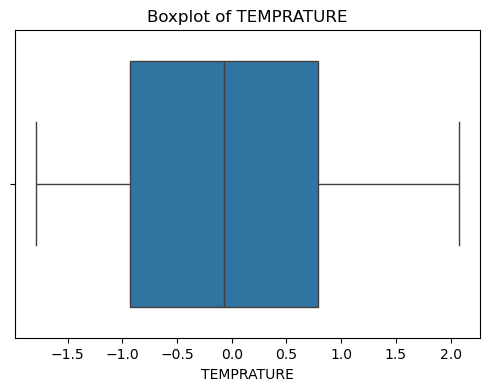

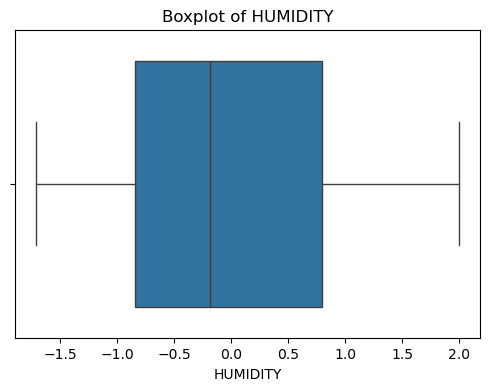

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_columns = ['CO2', 'NO2 ', 'TEMPRATURE', 'HUMIDITY']

for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

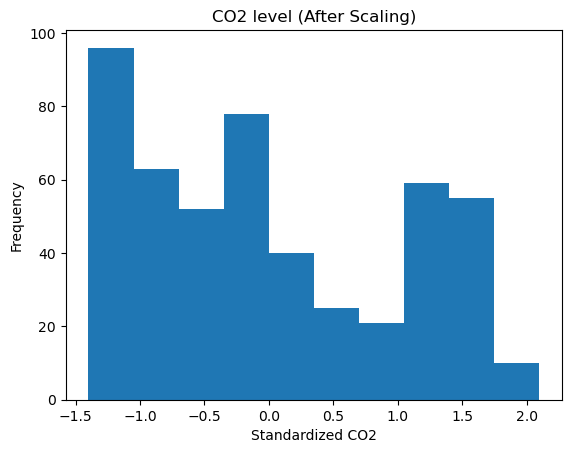

In [54]:
import matplotlib.pyplot as plt

# Histogram for scaled CO2
plt.hist(df["CO2"], bins=10)
plt.xlabel("Standardized CO2")
plt.ylabel("Frequency")
plt.title("CO2 level (After Scaling)")
plt.show()

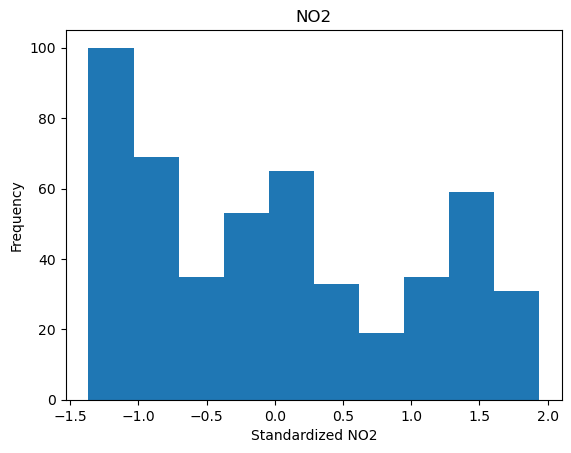

In [55]:
plt.hist(df["NO2 "], bins=10)
plt.xlabel("Standardized NO2")
plt.ylabel("Frequency")
plt.title("NO2")
plt.show()

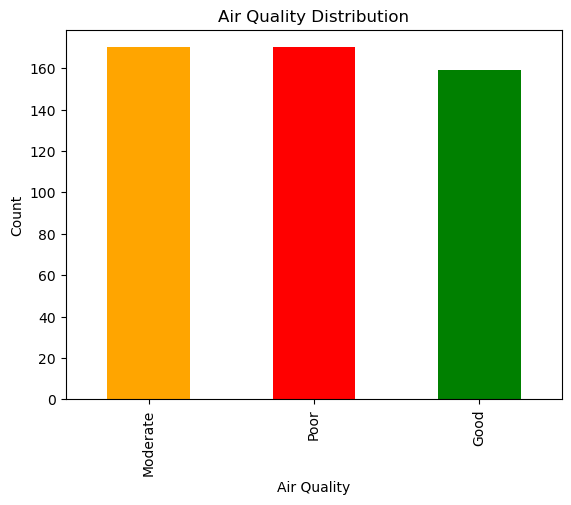

In [63]:
label_mapping = {0: "Good", 1: "Moderate", 2: "Poor"}
df['AIRR_QUALITY'] = df['AIR_QUALITY'].map(label_mapping)

df['AIR_QUALITY'].value_counts().plot(kind="bar", color=['orange', 'red', 'green'])
plt.xlabel("Air Quality")
plt.ylabel("Count")
plt.title("Air Quality Distribution")
plt.show()

In [65]:
for col in ['CO2', 'NO2 ', 'TEMPRATURE', 'HUMIDITY']:  
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} -> Number of Outliers: {outliers.shape[0]}")

CO2 -> Number of Outliers: 0
NO2  -> Number of Outliers: 0
TEMPRATURE -> Number of Outliers: 0
HUMIDITY -> Number of Outliers: 0


In [68]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['AIR_QUALITY'] = le.fit_transform(df['AIR_QUALITY'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Good': 0, 'Moderate': 1, 'Poor': 2}


In [70]:
# Correlation matrix
corr = df.corr()
print(corr)

                   CO2      NO2   TEMPRATURE  HUMIDITY  AIR_QUALITY  \
CO2           1.000000  0.996727    0.989760  0.990380     0.950762   
NO2           0.996727  1.000000    0.991906  0.992055     0.947148   
TEMPRATURE    0.989760  0.991906    1.000000  0.995236     0.938517   
HUMIDITY      0.990380  0.992055    0.995236  1.000000     0.932879   
AIR_QUALITY   0.950762  0.947148    0.938517  0.932879     1.000000   
AIRR_QUALITY       NaN       NaN         NaN       NaN          NaN   

              AIRR_QUALITY  
CO2                    NaN  
NO2                    NaN  
TEMPRATURE             NaN  
HUMIDITY               NaN  
AIR_QUALITY            NaN  
AIRR_QUALITY           NaN  


In [72]:
#correlation of all features with Air_Quality
print(corr["AIR_QUALITY"])

CO2             0.950762
NO2             0.947148
TEMPRATURE      0.938517
HUMIDITY        0.932879
AIR_QUALITY     1.000000
AIRR_QUALITY         NaN
Name: AIR_QUALITY, dtype: float64


In [73]:
selected_features = []

for col in corr.columns:
    if col != "AIR_QUALITY": 
        if abs(corr[col]["AIR_QUALITY"]) > 0.1:
            selected_features.append(col)

print("Selected Features:", selected_features)

Selected Features: ['CO2', 'NO2 ', 'TEMPRATURE', 'HUMIDITY']


In [76]:
X=df[selected_features]
y=df["AIR_QUALITY"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred

array([0, 2, 0, 2, 0, 1, 2, 1, 1, 2, 1, 1, 2, 2, 0, 0, 0, 2, 2, 0, 0, 0,
       1, 1, 0, 1, 2, 2, 0, 2, 0, 2, 2, 0, 2, 2, 1, 0, 2, 1, 2, 0, 2, 0,
       0, 1, 0, 0, 1, 2, 2, 1, 1, 2, 2, 2, 1, 2, 2, 1, 1, 0, 2, 1, 0, 0,
       1, 2, 1, 2, 1, 2, 1, 1, 0, 2, 2, 1, 2, 1, 2, 1, 1, 0, 1, 0, 0, 0,
       2, 2, 1, 0, 1, 1, 2, 1, 1, 0, 0, 1])

In [79]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (macro):", precision_score(y_test, y_pred, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred, average='macro'))
print("F1 Score (macro):", f1_score(y_test, y_pred, average='macro'))

Accuracy: 1.0
Precision (macro): 1.0
Recall (macro): 1.0
F1 Score (macro): 1.0
